# 02 — Baseline CNN
**WikiArt Painting Classifier** — NOVA IMS Deep Learning 2025/2026

This notebook implements a shallow Convolutional Neural Network (CNN) using the Keras framework. The primary objective is to confirm that the data processed by the EDA stage is loading correctly and that the model can achieve a baseline accuracy before we move to more complex architectures.

This notebook covers:
1. Loading the pre-processed WikiArt dataset using our custom `data_loader.py`.
2. Initializing the Baseline architecture.
3. Training with **Early Stopping** to prevent overfitting.
4. Saving results for final evaluation and reporting.

In [1]:
import sys
import os
import tensorflow as tf
import matplotlib.pyplot as plt

# Add the project root to the path
sys.path.insert(0, os.path.abspath(".."))

from src.data_loader import build_datasets
from src.models.baseline import build_baseline_model

# Global Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30


## 1. Loading the Pre-processed WikiArt Dataset
We use the `build_datasets` function to create TensorFlow Dataset objects. By setting `use_processed=True`, we efficiently load the images already resized and normalized during the EDA phase, avoiding redundant computations.

In [2]:
train_ds, val_ds, test_ds, NUM_CLASSES = build_datasets(
    splits_dir="../data/splits",
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    augment_train=True,      
    use_processed=True,      
    processed_dir="../data/processed"
)

print(f"Dataset loaded with {NUM_CLASSES} classes.")

Dataset loaded with 23 classes.


## 2. Initializing the Baseline Architecture
Following the "Approach" guidelines in the assignment, we identify the need for a model that balances complexity and computational cost. Our baseline consists of a shallow CNN with:
* **Conv2D + MaxPooling**: For basic feature extraction.
* **Dropout (0.5)**: To mitigate overfitting

In [3]:
# Instantiate the Keras model
model = build_baseline_model(num_classes=NUM_CLASSES, input_shape=(224, 224, 3))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,910,359 (91.21 MB)

 Trainable params: 23,910,359 (91.21 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Training with Early Stopping
To ensure the model is generalizable, we use **Early Stopping**. This technique monitors the `val_loss` and terminates training if the model stops improving, preventing the network from simply memorizing the training data.

In [4]:
os.makedirs('../results/logs', exist_ok=True)

# One-hot encode labels for F1Score metric compatibility
train_ds_oh = train_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)))
val_ds_oh = val_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)))

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='f1_macro')]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.CSVLogger('../results/logs/baseline.csv')
]

# Training Execution
history = model.fit(
    train_ds_oh,
    validation_data=val_ds_oh,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 46s 156ms/step - accuracy: 0.1439 - f1_macro: 0.0629 - loss: 3.1014 - val_accuracy: 0.2139 - val_f1_macro: 0.0961 - val_loss: 2.7101
Epoch 2/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 46s 156ms/step - accuracy: 0.2144 - f1_macro: 0.1343 - loss: 2.7246 - val_accuracy: 0.2674 - val_f1_macro: 0.1632 - val_loss: 2.5366
Epoch 3/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 46s 156ms/step - accuracy: 0.2559 - f1_macro: 0.1838 - loss: 2.5742 - val_accuracy: 0.3148 - val_f1_macro: 0.2141 - val_loss: 2.3794
Epoch 4/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 45s 153ms/step - accuracy: 0.2992 - f1_macro: 0.2426 - loss: 2.4033 - val_accuracy: 0.3298 - val_f1_macro: 0.2361 - val_loss: 2.3008
Epoch 5/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 45s 155ms/step - accuracy: 0.3343 - f1_macro: 0.2887 - loss: 2.2392 - val_accuracy: 0.3518 - val_f1_macro: 0.2685 - val_loss: 2.2863
Epoch 6/30
292/292 ━━━━━━━━━━━━━━━━━━━━ 45s 154ms/step - accuracy: 0.3905 - f1_macro: 0.3555 - loss: 2.0421 - val_accuracy: 0.3618 - va

## 4. Saving Results for Evaluation
Export the model and analyze the learning curves. 

Figure saved to: ../results/figures\baseline_learning_curves.png


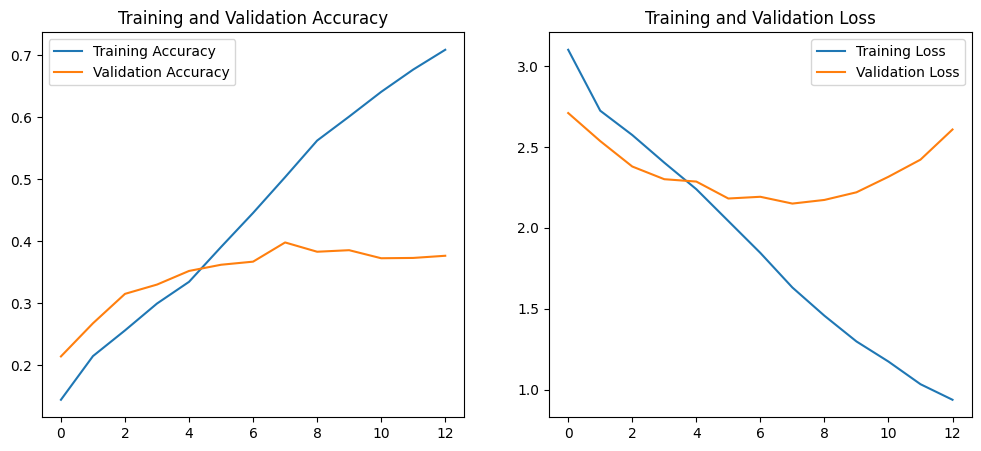

In [5]:
os.makedirs('../results/models', exist_ok=True)
model.save('../results/models/baseline_cnn.keras')

# Comparing Accuracy and Loss throughout the training and validation process
def plot_baseline_results(history, filename="baseline_learning_curves.png"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    
    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    os.makedirs('../results/figures', exist_ok=True)
    
    save_path = os.path.join('../results/figures', filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {save_path}")
    
    plt.show()

plot_baseline_results(history)